In [314]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
import numpy as np
import matplotlib.pyplot as plt




sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42  


TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

In [315]:
taxi=pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv")

<class 'pandas.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB


<Axes: xlabel='tip_amount', ylabel='Count'>

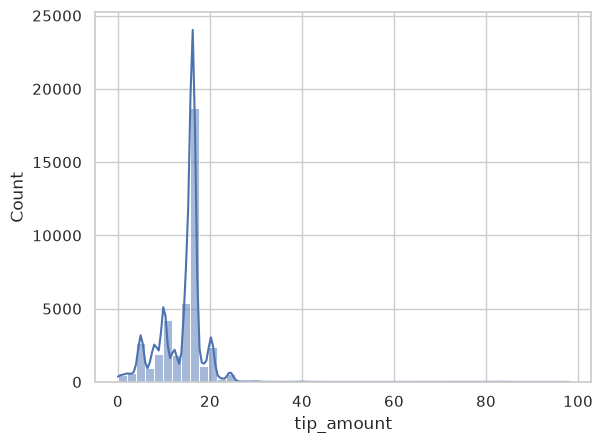

In [316]:
taxi.shape
taxi.head()
taxi.info()
taxi.describe()
taxi.isna().sum()
sns.histplot(data=taxi, x="tip_amount", bins=50, kde=True)


#there are no missing values or impossible values in the taxi dataset
#The histogram shows that the tip amount is right-skewed, with most tips being small amounts and a few larger tips.

#The data being skewed with a few outliers and no zeros tell me that there is no need for

In [317]:
# TODO: Handle missing / invalid rows

taxi.replace([np.inf, -np.inf], np.nan, inplace=True)
taxi = taxi[(taxi["trip_distance"] > 0) & (taxi["fare_amount"] > 0) & (taxi["tip_amount"] >= 0)].copy()

# TODO: Feature engineering — create at least ONE new, justified feature, for example:

taxi["fare_per_mile"] = taxi["fare_amount"] / taxi["trip_distance"]
taxi["total_surcharges"] = taxi["mta_tax"] + taxi["tolls_amount"] + taxi["improvement_surcharge"]

taxi.replace([np.inf, -np.inf], np.nan, inplace=True)
taxi.dropna(subset=["fare_per_mile", "total_surcharges"], inplace=True)

# TODO: Decide which columns are categorical (e.g. VendorID, RatecodeID, payment_type,
categorical_columns = ['VendorID', 'RatecodeID', 'payment_type', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID']
numeric_columns = ['passenger_count', 'trip_distance', 'fare_amount', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'fare_per_mile', 'total_surcharges']
#   store_and_fwd_flag) vs numeric, and encode the categoricals (pd.get_dummies or OneHotEncoder).
categorical_data = taxi[categorical_columns]
encoder = OneHotEncoder(drop='first', sparse_output=False)  # drop first to avoid multicollinearity
encoded_categorical_data = encoder.fit_transform(categorical_data)

encoded_categorical_df = pd.DataFrame(
	encoded_categorical_data,
	columns=encoder.get_feature_names_out(categorical_columns),
	index=taxi.index
)
taxi = pd.concat([taxi, encoded_categorical_df], axis=1)

# TODO: Scale the numeric features.

numeric_data = taxi[numeric_columns]
scaler = StandardScaler()
taxi[numeric_columns] = scaler.fit_transform(numeric_data)

# how many zero-distance trips?
distance_zero_count = (taxi['trip_distance'] == 0).sum()
print(f"Number of zero-distance trips: {distance_zero_count}")

#There were no missing values or impossible values in the taxi dataset.
#new features: fare_per_mile and total_surcharges were created to provide additional insights into the fare structure and surcharges associated with each trip. 
# These features can help in understanding the relationship between fare amount, trip distance, and additional charges.
#i choose to encode categorical variables using OneHotEncoder to avoid introducing any ordered relationships between categories.





Number of zero-distance trips: 0


In [318]:
from sklearn.model_selection import train_test_split
# TODO: Separate features (X) and target (y = tip_amount)

X = taxi.drop(columns=['tip_amount'])
y = taxi['tip_amount']

# TODO: Split into train / validation / test (a common choice is 60/20/20).
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE)



# TODO: Fit your scaler on the TRAINING set only, then transform train, val, and test.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

#(Explain in the reasoning box why scaling must be fit on train only.)
#if i scale the test and validation data, information from those sets would leak into the training process, leading to overfitting and unrealistic performance metrics. 
#By fitting the scaler only on the training data, i ensure that the model learns to generalize to unseen data without being influenced by it.



Train rmse: 0.9538, r^2: 0.0592
Validation rmse: 0.9528, r^2: 0.0664
Test rmse: 1.0424, r^2: 0.0356


/tmp/ipykernel_23118/2764265765.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


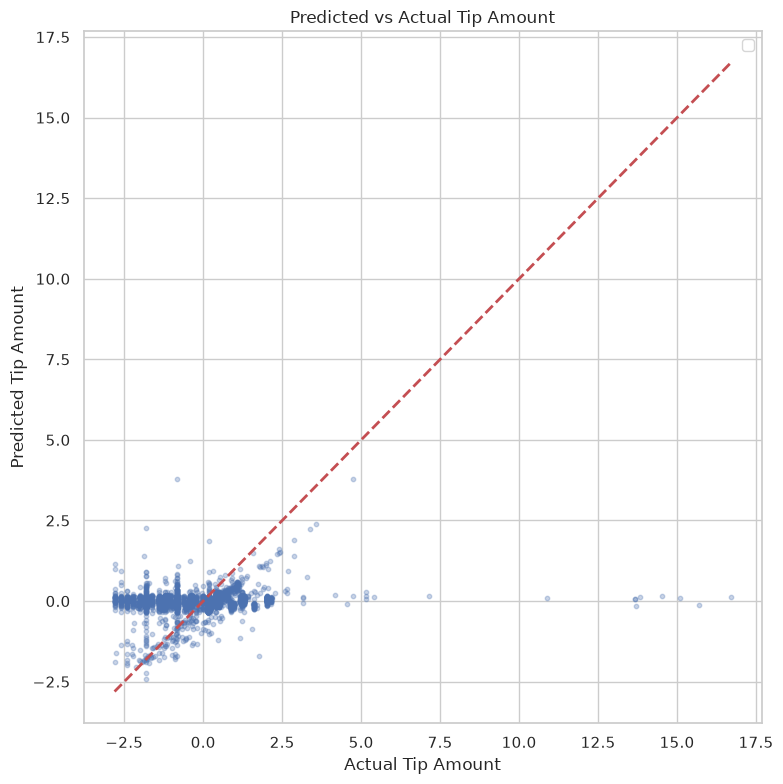

In [319]:
# TODO: Import, initialise, and train a regression model.


#fitting the model on the training data
model = LinearRegression()
model.fit(X_train_scaled, y_train)



# TODO: Predict on train, validation, and test sets.
y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

# TODO: Report RMSE and R^2 for ALL THREE sets.

train_rmse = mean_squared_error(y_train, y_train_pred) ** 0.5
val_rmse = mean_squared_error(y_val, y_val_pred) ** 0.5
test_rmse = mean_squared_error(y_test, y_test_pred) ** 0.5


train_r2 = r2_score(y_train, y_train_pred)
val_r2 = r2_score(y_val, y_val_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"Train rmse: {train_rmse:.4f}, r^2: {train_r2:.4f}")
print(f"Validation rmse: {val_rmse:.4f}, r^2: {val_r2:.4f}")
print(f"Test rmse: {test_rmse:.4f}, r^2: {test_r2:.4f}")





# TODOPlot predicted vs actual tip for the test set (a scatter with the y=x line).
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_test_pred, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Tip Amount')
plt.ylabel('Predicted Tip Amount')
plt.title('Predicted vs Actual Tip Amount')
plt.legend()
plt.tight_layout()
plt.show()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

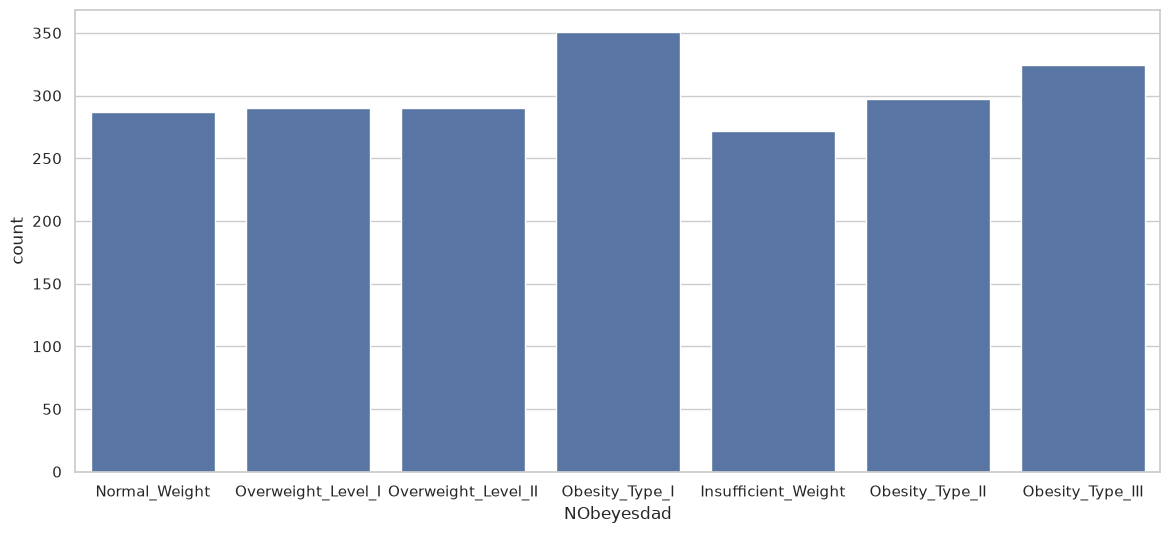

In [320]:
obesity=pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv")
obesity.shape
obesity.head()
obesity.info()
obesity.describe()
obesity.isna().sum()
plt.figure(figsize=(14, 6))
sns.countplot(data=obesity, x='NObeyesdad')
value_counts = obesity['NObeyesdad'].value_counts()
print(value_counts)

#There 17 colums(features) and 2111 rows in the obesity dataset.
#Caregorical colums are ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS', 'NObeyesdad']
#Numeric colums are ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']
#The target variable is not balenced, with the majority of samples falling into the "Normal_Weight" category. 
# class imbalance matters in classification because a model can achieve high accuracy by simply predicting the majority class, but 
# it may perform poorly on minority classes, leading to biased and unreliable predictions.


In [321]:
# TODO: Encode categorical columns.
binary_columns = ['family_history_with_overweight', 'FAVC', 'SMOKE', 'SCC']
for col in binary_columns:
    obesity[col] = obesity[col].map({'yes': 1, 'no': 0})

print(obesity['CAEC'].unique())
print(obesity['CALC'].unique())

from sklearn.preprocessing import OrdinalEncoder
caec_order =['Sometimes', 'Frequently', 'Always', 'no']
calc_order=['no', 'Sometimes', 'Frequently', 'Always']

caec_encoder = OrdinalEncoder(categories=[caec_order])
calc_encoder = OrdinalEncoder(categories=[calc_order])

obesity['CAEC'] = caec_encoder.fit_transform(obesity[['CAEC']])
obesity['CALC'] = calc_encoder.fit_transform(obesity[['CALC']])
#i chose to use ordinal encoding for CAEC and CALC because they have a natural order of frequency, which can be captured by assigning integer values.

nominal_columns = ['Gender', 'MTRANS']
obesity = pd.get_dummies(obesity, columns=nominal_columns, drop_first=True)
# i chhoose to use normal encoding for Gender and MTRANS because they are categorical variables without a natural order, 
# and one-hot encoding allows the model to learn separate weights for each category without introducing any ordinal relationships.

#
# TODO (optional but encouraged): engineer a domain feature, e.g. BMI = Weight / Height**2.
BMI = obesity['Weight'] / (obesity['Height'] ** 2)
obesity['BMI'] = BMI

#the bmi feature doesnot leak the target variable, but it is highly correlated with the target variable.


# TODO: Encode the target `NObeyesdad` into integer class labels
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
obesity['NObeyesdad'] = label_encoder.fit_transform(obesity['NObeyesdad'])

# TODO: Scale the numeric features (fit on TRAIN only, in Part 2.3).
X = obesity.drop(columns=['NObeyesdad'])
y = obesity['NObeyesdad']

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE)

numeric_columns = ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'CAEC', 'CALC', 'BMI']
scaler = StandardScaler()
#I used StandardScaler to scale the numeric features because it standardizes the features by removing the mean and scaling to unit variance, 
# which is important for many machine learning algorithms that are sensitive to the scale of input data.

#fitting data on train only
X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_val[numeric_columns] = scaler.transform(X_val[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])






<StringArray>
['Sometimes', 'Frequently', 'Always', 'no']
Length: 4, dtype: str
<StringArray>
['no', 'Sometimes', 'Frequently', 'Always']
Length: 4, dtype: str


In [322]:
# TODO: Separate X (features) and y (encoded NObeyesdad).
X = obesity.drop(columns=['NObeyesdad'])
y = obesity['NObeyesdad']

# TODO: Split into train / validation / test using stratify=y so every split has all 7 classes.
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=RANDOM_STATE)


# TODO: Fit the scaler on the training set only, then transform train / val / test.
X_train[numeric_columns] = scaler.fit_transform(X_train[numeric_columns])
X_val[numeric_columns] = scaler.transform(X_val[numeric_columns])
X_test[numeric_columns] = scaler.transform(X_test[numeric_columns])

#i chose a 60/20/20 split for the train, validation, and test sets to ensure that the model has enough data to learn from while also having sufficient data for validation and testing.
# stratisty = y is used to ensure that the class distribution is preserved in each split, which is important for imbalanced datasets like this one.
#if stratify=y is not used, the class distribution in the train, validation, and test sets may not reflect the original distribution in the dataset, 
# leading to biased model performance and inaccurate evaluation metrics.




Train Accuracy: 0.8973, Macro-F1: 0.8888

Validation Accuracy: 0.8365, Macro-F1: 0.8247

Test Accuracy: 0.8298, Macro-F1: 0.8145



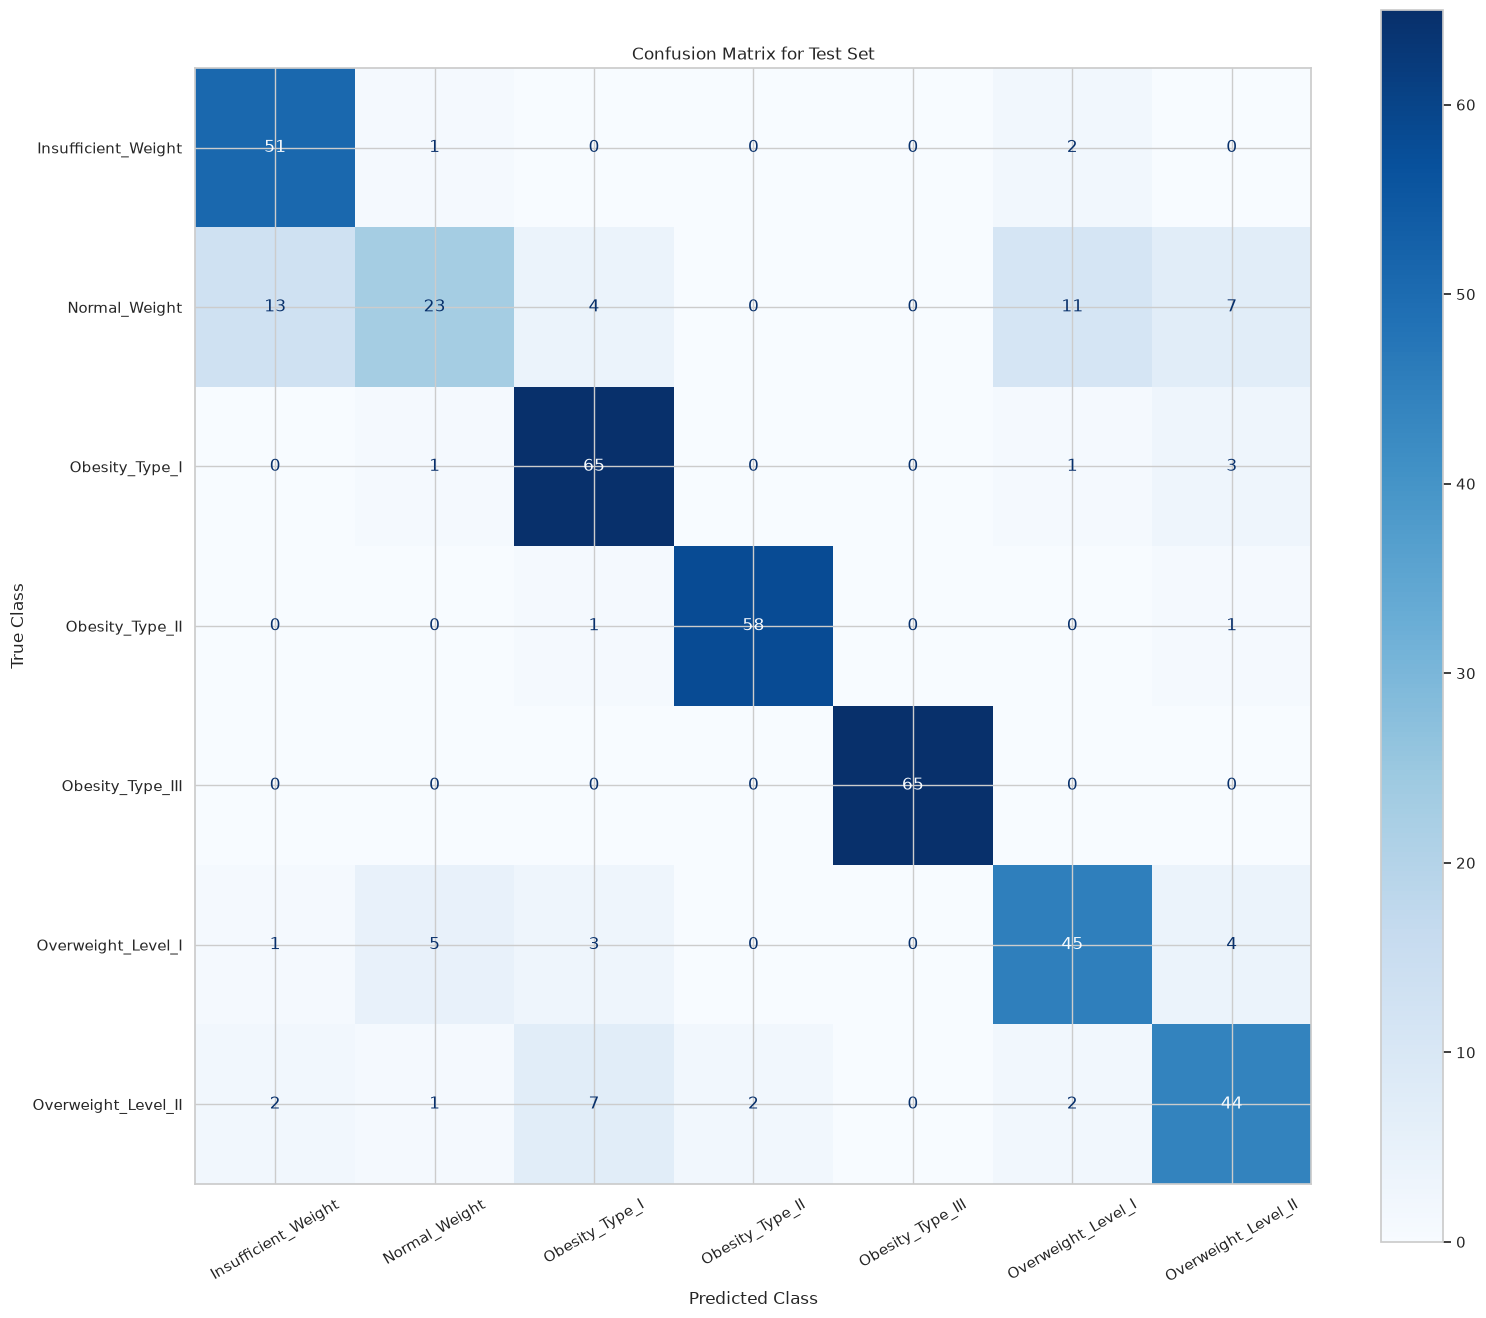

In [323]:
# TODO: Import, initialise, and train a classifier
#   (e.g. LogisticRegression(max_iter=...), RandomForestClassifier, or KNeighborsClassifier).
#fitting the model on the training data
from sklearn.neighbors import KNeighborsClassifier


model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)






# TODO: Predict on train, validation, and test.
train_preds = model.predict(X_train)
val_preds = model.predict(X_val)
test_preds = model.predict(X_test)

# TODO: Report accuracy AND macro-F1 for ALL THREE sets
#   from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import accuracy_score, f1_score, classification_report
train_accuracy = accuracy_score(y_train, train_preds)
val_accuracy = accuracy_score(y_val, val_preds)
test_accuracy = accuracy_score(y_test, test_preds)

train_f1 = f1_score(y_train, train_preds, average='macro')
val_f1 = f1_score(y_val, val_preds, average='macro')
test_f1 = f1_score(y_test, test_preds, average='macro')

train_report = classification_report(y_train, train_preds, target_names=label_encoder.classes_)
val_report = classification_report(y_val, val_preds, target_names=label_encoder.classes_)
test_report = classification_report(y_test, test_preds, target_names=label_encoder.classes_)

print(f"Train Accuracy: {train_accuracy:.4f}, Macro-F1: {train_f1:.4f}\n")

print(f"Validation Accuracy: {val_accuracy:.4f}, Macro-F1: {val_f1:.4f}\n")
print(f"Test Accuracy: {test_accuracy:.4f}, Macro-F1: {test_f1:.4f}\n")


# TODO: Show a confusion matrix for the test set
#   from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(figsize=(18, 16))

cm = ConfusionMatrixDisplay.from_predictions(
	y_test,
	test_preds,
	labels=model.classes_,
	display_labels=label_encoder.classes_,
    xticks_rotation=30,
    ax=ax,
    cmap='Blues'
   
)
ax.set_title('Confusion Matrix for Test Set')
ax.set_xlabel('Predicted Class')
ax.set_ylabel('True Class')
plt.show()




#   Which classes are most often confused?
#The classes that are most confused are: Normal weight, overweight 1 and Overweight 2.
#i choose the k-nearest neighbors classifier because it is a simple and effective algorithm that can handle multi-class classification problems.
# from the comparison of accuracy and f1 scores across the train, validation, and test sets, the model appears to generalize well to unseen data, with similar performance metrics across all three sets.
#this implies that the model is well fitted.
# One of the classes the were harder to tell apart is the normal weight class, which predicted obesity type ,4 times and insufficient weight 13 times. This is likely because normal weight sits in the middle of the weight spectrum between overweight and underweight, there is no sharp biological distinction between normal weight and overweight or underweight.


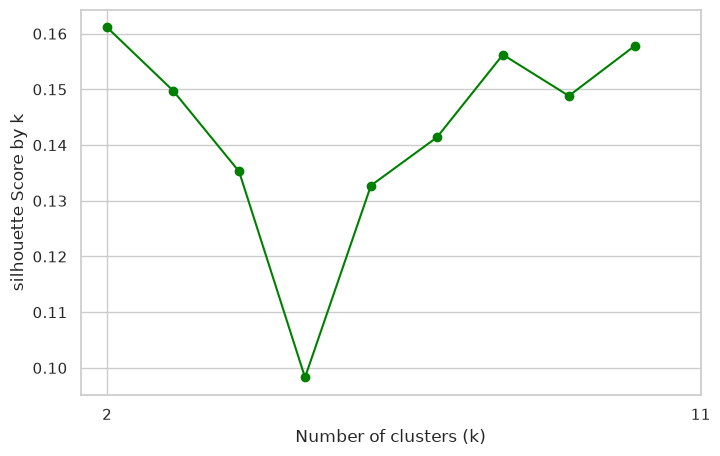

Chosen k: 2
Silhouette score at k=2: 0.1611


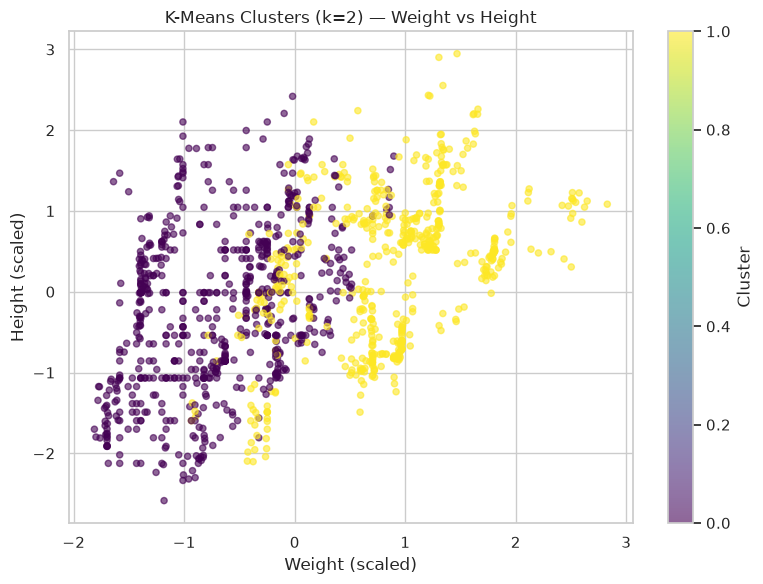

In [324]:
# TODO: Use ONLY the scaled obesity features (no target) for clustering.

# TODO: Choose the number of clusters k with the Elbow method (and/or silhouette score).
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

X_cluster = X_train[numeric_columns]  # Use only the scaled numeric features for clustering

silhouette_scores = []

#   Loop k = 2..10, record inertia_ (and silhouette), and plot inertia vs k.
for k in range(2,11):
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X_cluster)
    score = silhouette_score(X_cluster, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), silhouette_scores, marker='o', color='green')
plt.xlabel('Number of clusters (k)')
plt.ylabel('silhouette Score by k')
plt.xticks([2,11])
plt.show()
    
# TODO: Fit KMeans with your chosen k (random_state=RANDOM_STATE) and get cluster labels.
chosen_k = 2

print(f"Chosen k: {chosen_k}")
print(f"Silhouette score at k={chosen_k}: {silhouette_scores[chosen_k - 2]:.4f}")

kmeans = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=10)
kmeans.fit(X_cluster)
cluster_labels = kmeans.labels_
# TODO: Visualise the clusters in 2D.

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_cluster['Weight'], X_cluster['Height'], c=cluster_labels, cmap='viridis', alpha=0.6, s=20)
plt.xlabel('Weight (scaled)')
plt.ylabel('Height (scaled)')
plt.title(f'K-Means Clusters (k={chosen_k}) — Weight vs Height')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()
#   Pick two informative features (e.g. Weight vs Height) OR reduce to 2D with PCA
#   (from sklearn.decomposition import PCA) and colour points by cluster.

col_0  Insufficient_Weight  Normal_Weight  Obesity_Type_I  Obesity_Type_II  \
row_0                                                                        
0                      163            170             102                1   
1                        0              2             109              177   

col_0  Obesity_Type_III  Overweight_Level_I  Overweight_Level_II  
row_0                                                             
0                     0                 153                  101  
1                   194                  21                   73  


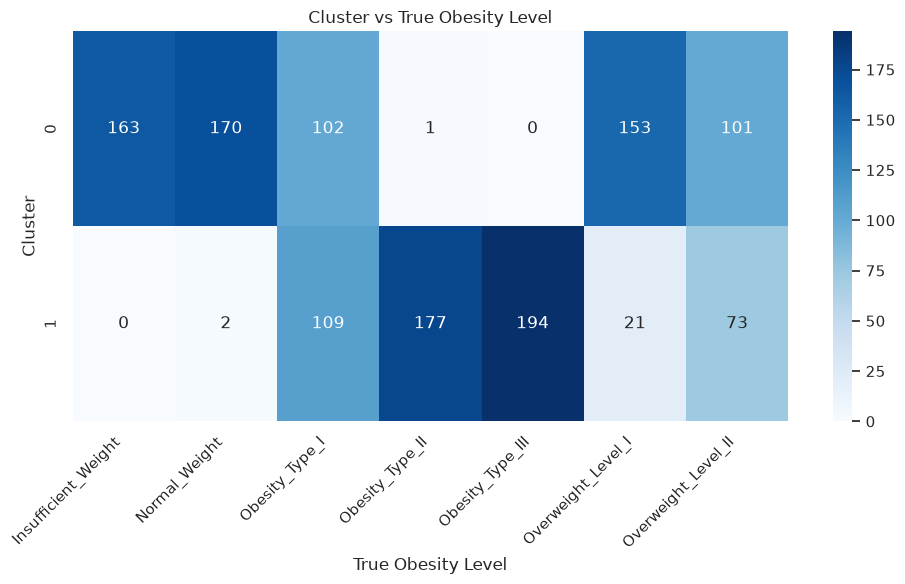

In [325]:
# TODO: How well do the clusters line up with the TRUE obesity levels?
import pandas as pd


true_labels = obesity.loc[X_cluster.index, 'NObeyesdad']




# If you have a label_encoder from earlier, decode back to names
true_labels_named = label_encoder.inverse_transform(true_labels) if true_labels.dtype != 'object' else true_labels
crosstab = pd.crosstab(cluster_labels, true_labels_named)
print(crosstab)

import seaborn as sns
import matplotlib.pyplot as plt

#visualising outcome
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
plt.xlabel('True Obesity Level')
plt.ylabel('Cluster')
plt.title('Cluster vs True Obesity Level')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [326]:
#QUESTIONS

#How did you choose k?
#Quote the Elbow/silhouette evidence. 2. 
#Looking at the crosstab, do the unsupervised clusters resemble the real obesity levels?
#W#here do they agree and where do they break down? 3. In a real public-health setting where labels are expensive to collect, what would these clusters be useful for

#ANSWERS
# i chose k  by looking at the k that has the highest silhoutte score
#The clusters partially resemble the real obesity levels Cluster 1 cleanly captures the most extreme categories (Obesity_Type_II and Obesity_Type_III), 
#while Cluster 0 lumps together everything else without distinguishing between the remaining five levels. This shows K-Means found genuine structure related to obesity level, 
#but with only k=2 it can't separate the finer gradations that the true 7-class labeling captures.
#The clusters get the extreme case right Cluster 1 mostly holds Obesity_Type_II and Obesity_Type_III.
# But in the middle, it mixes five different real categories into one cluster and can't tell them apart
#Usefulness: Even without labels, this clustering could help flag likely high-risk (severely obese) people first, for cheap early screening.




In [327]:
    #Reflection Questions

# 1. Supervised vs unsupervised: What did the classifier learn that K-Means could not, and vice-versa?
#    The classifier learned exact boundaries between all 7 obesity levels, since it had access to true labels.
#    K-Means only found the broadest split (severe obesity vs. rest), since it had no labels to learn fine-grained boundaries from.

# 2. Regression vs classification: How did evaluating a continuous target (tips) differ from evaluating a categorical one (obesity level)?
#    Tip prediction was evaluated with error-based metrics (RMSE, R^2), since the target is a continuous number.
#    Obesity level was evaluated with a confusion matrix and accuracy-type metrics, since the target is a discrete category.

# 3. Overfitting: Across all three tasks, where did you see the biggest train-vs-test gap, and what is the single most effective thing you did (or would do) to close it?
#    There wasn't a large train-vs-test gap; instead, the tip regression model underfit (low r^2 on both train and test).
#    The most effective fix would be  switching to a non-linear model like Random Forest.